In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the pre-pruning state
df_train = pd.read_csv('../data/df_train_v2.csv')

# Reload pruned encoded matrices and feature names
X_train_pruned = np.load('../data/X_train_pruned.npy')
X_test_pruned = np.load('../data/X_test_pruned.npy')
pruned_feature_names = np.load('../data/pruned_feature_names.npy', allow_pickle=True)
y_train = df_train['target']

print(f"X_train_pruned shape: {X_train_pruned.shape}")
print(f"Number of features: {len(pruned_feature_names)}")
print(f"y_train length: {len(y_train)}")
print(f"\nFirst 10 feature names:")
for name in pruned_feature_names[:10]:
    print(f"  {name}")

X_train_pruned shape: (78283, 92)
Number of features: 92
y_train length: 78283

First 10 feature names:
  num__time_in_hospital
  num__num_lab_procedures
  num__num_procedures
  num__num_medications
  num__number_outpatient
  num__number_emergency
  num__number_inpatient
  num__number_diagnoses
  num__weight_recorded
  bin__gender


/tmp/ipykernel_20168/1287199694.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
/tmp/ipykernel_20168/1287199694.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
/tmp/ipykernel_20168/1287199694.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
/tmp/ipykernel_20168/1287199694.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
/tmp/ipykernel_20168/1287199694.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

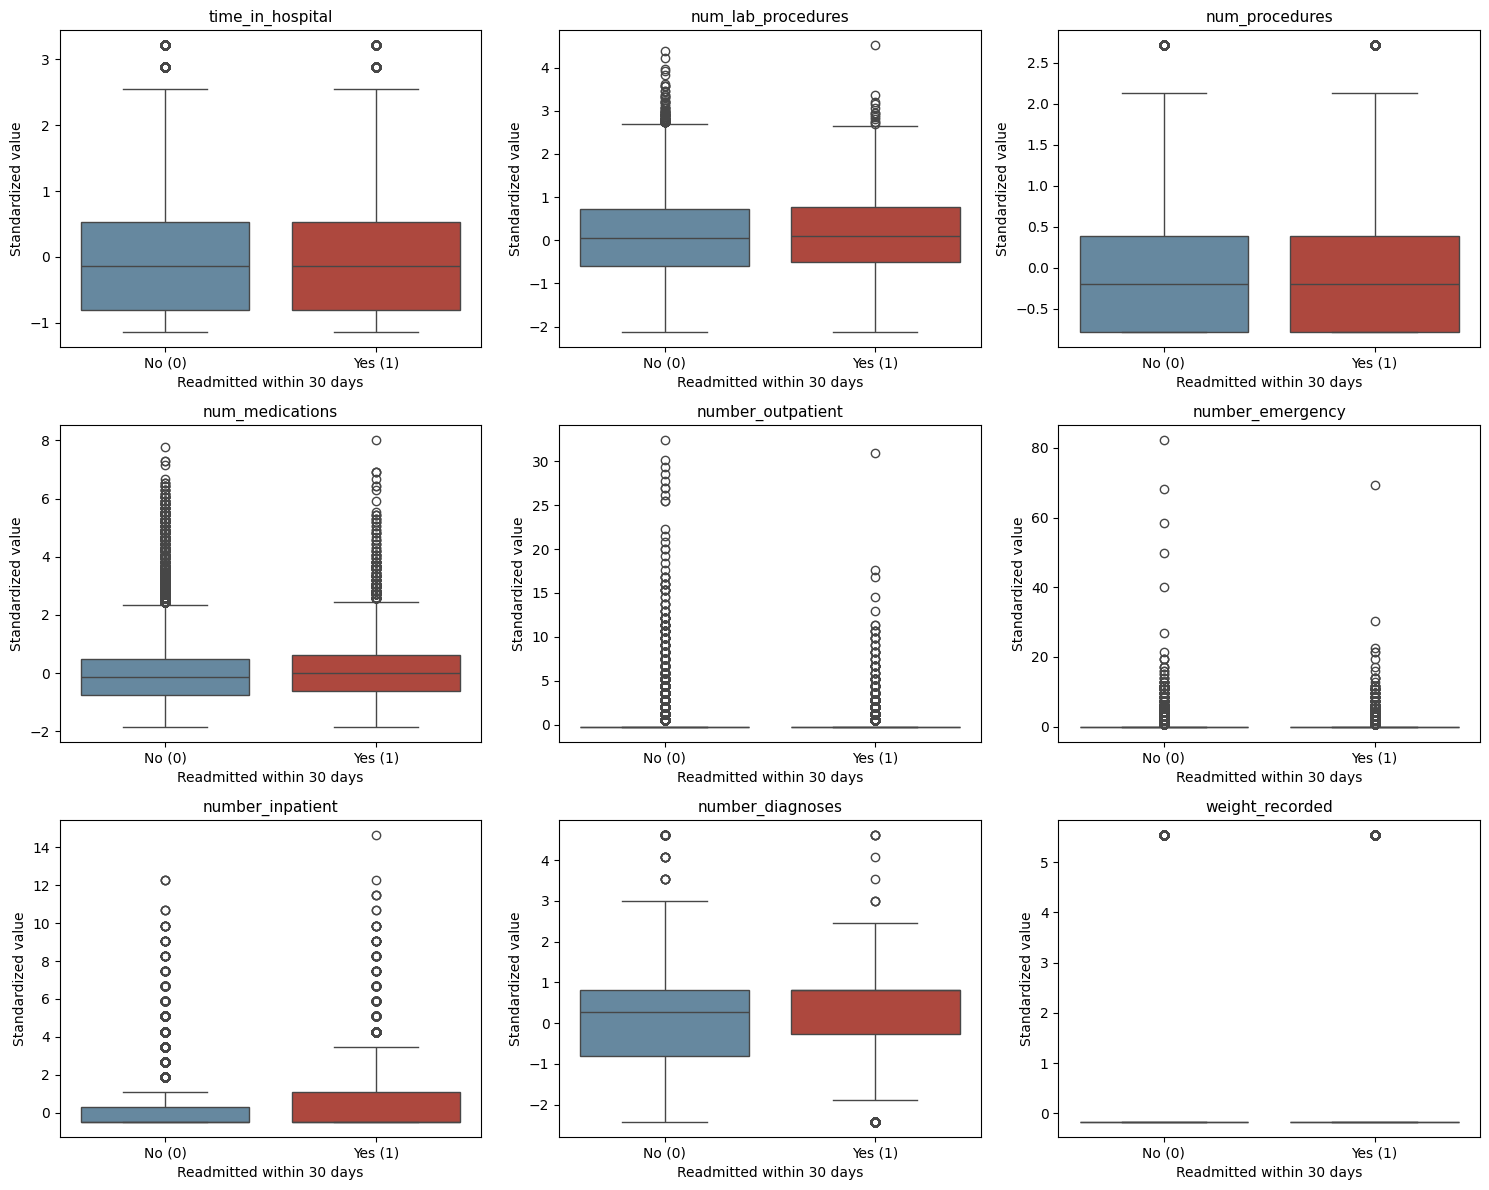

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_feature_names = [name for name in pruned_feature_names if name.startswith('num__')]

plot_data = pd.DataFrame(
    X_train_pruned[:, :len(numeric_feature_names)],
    columns=numeric_feature_names
)
plot_data['target'] = y_train.values.astype(int)  # explicit int

clean_names = [n.replace('num__', '') for n in numeric_feature_names]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (feature, clean_name) in enumerate(zip(numeric_feature_names, clean_names)):
    sns.boxplot(
        data=plot_data,
        x='target',
        y=feature,
        hue='target',                          # NEW: assign hue
        palette={0: '#5d8aa8', 1: '#c0392b'},
        legend=False,                          # NEW: suppress redundant legend
        ax=axes[idx]
    )
    axes[idx].set_title(clean_name, fontsize=11)
    axes[idx].set_xlabel('Readmitted within 30 days')
    axes[idx].set_ylabel('Standardized value')
    axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.savefig('figures/numeric_features_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# Quantitative measure: difference in means between readmitted vs not-readmitted
# Plus a simple t-test for whether the difference is statistically meaningful

from scipy import stats

results = []
for feature in numeric_feature_names:
    feature_idx = list(pruned_feature_names).index(feature)
    values = X_train_pruned[:, feature_idx]
    
    values_pos = values[y_train == 1]
    values_neg = values[y_train == 0]
    
    mean_pos = values_pos.mean()
    mean_neg = values_neg.mean()
    diff = mean_pos - mean_neg  # positive = readmitted patients have higher values
    
    # Cohen's d — standardized effect size, accounts for variance
    pooled_std = np.sqrt(((len(values_pos) - 1) * values_pos.var() + 
                          (len(values_neg) - 1) * values_neg.var()) / 
                         (len(values_pos) + len(values_neg) - 2))
    cohens_d = diff / pooled_std if pooled_std > 0 else 0
    
    # T-test for the difference
    t_stat, p_value = stats.ttest_ind(values_pos, values_neg, equal_var=False)
    
    results.append({
        'feature': feature.replace('num__', ''),
        'mean_no': round(mean_neg, 4),
        'mean_yes': round(mean_pos, 4),
        'diff': round(diff, 4),
        'cohens_d': round(cohens_d, 4),
        'p_value': p_value
    })

results_df = pd.DataFrame(results).sort_values('cohens_d', key=abs, ascending=False)
print(results_df.to_string(index=False))

           feature  mean_no  mean_yes    diff  cohens_d       p_value
  number_inpatient  -0.0598    0.4678  0.5276    0.5351 1.746685e-210
  number_emergency  -0.0235    0.1836  0.2070    0.2075  1.027456e-36
  number_diagnoses  -0.0181    0.1419  0.1600    0.1602  9.485701e-52
  time_in_hospital  -0.0161    0.1256  0.1417    0.1418  1.024733e-34
   num_medications  -0.0145    0.1137  0.1282    0.1283  1.231765e-29
num_lab_procedures  -0.0080    0.0624  0.0703    0.0704  2.489683e-10
 number_outpatient  -0.0074    0.0582  0.0656    0.0656  2.444114e-08
    num_procedures   0.0038   -0.0300 -0.0339   -0.0339  1.942513e-03
   weight_recorded   0.0003   -0.0022 -0.0025   -0.0025  8.246491e-01


In [7]:
# For each one-hot dummy, compute readmission rate when feature = 1
# Compare to population baseline (overall readmission rate)

baseline_rate = y_train.mean()
print(f"Population readmission rate: {baseline_rate:.4f} ({baseline_rate*100:.2f}%)\n")

# Get all non-numeric features
non_numeric = [name for name in pruned_feature_names if not name.startswith('num__')]
print(f"Non-numeric features to audit: {len(non_numeric)}\n")

results = []
for feature in non_numeric:
    feature_idx = list(pruned_feature_names).index(feature)
    values = X_train_pruned[:, feature_idx]
    
    # For binary/dummy features, look at readmission rate when value > 0
    # (for ordinal age, value > 0 just means "older than the reference")
    mask_pos = values > 0
    mask_neg = values == 0
    
    if mask_pos.sum() == 0 or mask_neg.sum() == 0:
        continue  # skip constants
    
    rate_when_present = y_train[mask_pos].mean()
    rate_when_absent = y_train[mask_neg].mean()
    diff = rate_when_present - rate_when_absent
    
    results.append({
        'feature': feature,
        'n_present': mask_pos.sum(),
        'rate_present': round(rate_when_present, 4),
        'rate_absent': round(rate_when_absent, 4),
        'diff_pp': round(diff * 100, 2),  # percentage points
        'abs_diff_pp': round(abs(diff) * 100, 2)
    })

cat_results = pd.DataFrame(results).sort_values('abs_diff_pp', ascending=False)
print(f"Top 25 categorical features by absolute difference in readmission rate:")
print(cat_results.head(25).to_string(index=False))

Population readmission rate: 0.1133 (11.33%)

Non-numeric features to audit: 83

Top 25 categorical features by absolute difference in readmission rate:
                                          feature  n_present  rate_present  rate_absent  diff_pp  abs_diff_pp
                 nom__discharge_disposition_id_22       1586        0.2730       0.1100    16.30        16.30
                  nom__discharge_disposition_id_5        929        0.2153       0.1121    10.32        10.32
                                         ord__age      78225        0.1134       0.0172     9.61         9.61
                nom__medical_specialty_Nephrology       1241        0.1708       0.1124     5.84         5.84
                  nom__discharge_disposition_id_2       1709        0.1621       0.1122     4.99         4.99
                            nom__diag_2_Neoplasms       1851        0.1578       0.1122     4.55         4.55
                          nom__max_glu_serum_>300        953        0.1574   

In [8]:
# Compute readmission rate by age bracket
age_idx = list(pruned_feature_names).index('ord__age')
age_values = X_train_pruned[:, age_idx].astype(int)

age_labels = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

print(f"{'Age bracket':<15} {'n':<8} {'Readmit rate':<12}")
for code in range(10):
    mask = age_values == code
    if mask.sum() > 0:
        rate = y_train[mask].mean()
        print(f"{age_labels[code]:<15} {mask.sum():<8} {rate:.4f}")

Age bracket     n        Readmit rate
[0-10)          58       0.0172
[10-20)         374      0.0642
[20-30)         1208     0.1407
[30-40)         2811     0.1071
[40-50)         7556     0.1087
[50-60)         13435    0.0997
[60-70)         17541    0.1109
[70-80)         20178    0.1189
[80-90)         13085    0.1246
[90-100)        2037     0.1163


## Predictive Power Audit

Following mentor feedback to "ensure predictors have predicting power," 
each feature was evaluated for individual contribution to the target.

### Numeric features (Cohen's d)
- Strong: number_inpatient (d=0.54)
- Modest: number_emergency, number_diagnoses, time_in_hospital, num_medications
- Weak (drop candidates): num_lab_procedures, number_outpatient, 
  num_procedures, weight_recorded

### Categorical features (absolute readmission rate difference from 11.46%)
- Strongest: discharge_disposition_id_22 (+16.3pp), id_5 (+10.3pp)
- Strong: medical_specialty_Nephrology (+5.8pp), diag_2/3_Neoplasms (+4.6/3.8pp)
- Modest: ~15 features with 2-5pp separation
- Weak (drop candidates): ~64 features with <2pp separation

The 92-feature space contains approximately 30 features with meaningful 
individual signal. The remaining ~62 features will be tested for 
contribution via forward/backward selection before final removal.